# Introduction to Neural Networks

## Problem Statement -Part A

To build a classifier that can use the given parameters to determine the signal strength or quality 

## Data Dictionary 

The data set contains information on various signal tests performed:

- Parameters: Various measurable signal parameters. 
- Signal Quality: Final signal strength or quality.

### Let us start by importing some libraries 

In [166]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization,Activation
from tensorflow.keras import optimizers
from tensorflow import keras
from h5py import File
from tensorflow.keras.utils import to_categorical

#### Part A - Q1 A- Understanding the structure of data

In [2]:
data = pd.read_csv ("NN Project Data - Signal.csv")
data.shape

(1599, 12)

### Observations

- The dataset has 1599 rows and 12 columns

### Part A - Q1 B - Null Values in dataset

In [3]:
null_percent = (data.isna().sum() / len(data)) * 100
print (null_percent)

Parameter 1        0.0
Parameter 2        0.0
Parameter 3        0.0
Parameter 4        0.0
Parameter 5        0.0
Parameter 6        0.0
Parameter 7        0.0
Parameter 8        0.0
Parameter 9        0.0
Parameter 10       0.0
Parameter 11       0.0
Signal_Strength    0.0
dtype: float64


### Observations

- There are no null values in the dataset

### Part A - Q1 C - Duplicate records and imputation

In [4]:
duplicate_data = data.duplicated().sum()
print (duplicate_data)

240


In [5]:
#dropping the duplicate values
deduplicated_data = data.drop_duplicates(keep="first")
deduplicated_data.shape

(1359, 12)

### Observations

- Dropped all the duplicate columns so that model does not learn same thing multiple times 
- The shape of the data after dropping is 1359 rows and 12 columns

### Part A - Q1 D - Target Variable visualization

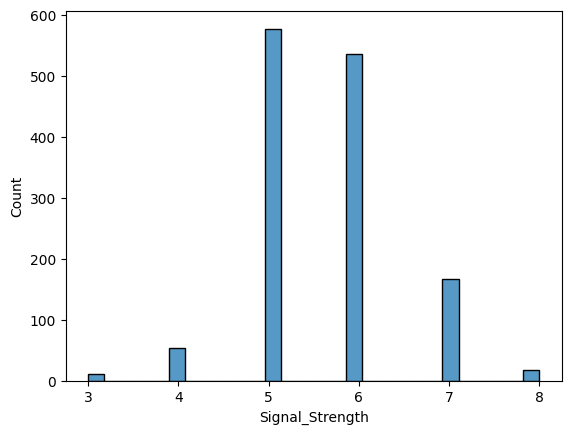

In [6]:
#plotting a violit plot for target variable
sns.histplot(deduplicated_data,x='Signal_Strength');

### Observations 

- More than 500 signals have signal strength of nearly 5 and 6  which is good but needs to be moved to higher strengths to attract customers
- There are very few that have signal strength of 7 and 8 and these have to be increased.
- Even signals having signal strength of 3 and 4 are very few but that is good.

### Insights 

- There are no null values in the data, hence imputation of unreal numbers based on statistic of other numbers was never a problem.
- There were duplicates in the dataset, which had to be removed so that model does not overlearn due to these duplicates
- The signal strength has to be increased from 5/6 to 7/8 to gain more traction among the customers. 

### Part A - Q2 A - Splitting the data into X & Y.

In [7]:
X = deduplicated_data.drop (columns = ['Signal_Strength'], axis=1)
y = deduplicated_data['Signal_Strength']

### Part A - Q2 B - Split the data into train & test with 70:30 proportion.

In [8]:
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

### Part A - Q2 C - Print shape of all the 4 variables and verify if train and test data is in sync.

In [9]:
print ("X_train shape", X_train.shape)
print ("X_test shape", X_test.shape)
print ("y_train shape", y_train.shape)
print ("y_test shape", y_test.shape)

X_train shape (951, 11)
X_test shape (408, 11)
y_train shape (951,)
y_test shape (408,)


### Part A - Q2 D - Normalise the train and test data with appropriate method.

In [10]:
X_train = preprocessing.normalize(X_train)
X_test = preprocessing.normalize(X_test)


### Insights/Recommendations

- Performs L2 normalization row-wise on the training features scaling each sample to unit norm.

### Part A - Q2 E - Transform Labels into format acceptable by Neural Network

In [11]:
y_train = np.array(y_train)
y_test  = np.array(y_test)

In [58]:
#label encoding on labels for multi-class classification
label_encoder = preprocessing.LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

### Part A - Q3 A - Design a Neural Network to train a classifier.

In [59]:
classifier_model = Sequential()
classifier_model.add(Dense(64, input_shape = (11,), activation = 'relu'))
classifier_model.add(BatchNormalization())
classifier_model.add(Dense(6, activation = 'softmax'))
opt = optimizers.Adam(learning_rate= 0.001)
classifier_model.compile(optimizer=opt, loss = 'crossentropy',metrics=["accuracy"])
classifier_model.summary()

c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,414 (5.52 KB)

 Trainable params: 1,286 (5.02 KB)

 Non-trainable params: 128 (512.00 B)

### Insights 

- A sequential model was chosen with one dense layer having 64 neurons followed by batch normalization and finally the output dense layer of 6 neurons with softmax activation function for multi-class classification.

### Part A - Q3 B - Train the classifier using previously designed Architecture

In [60]:
#training of the model
classifier_model_training_outputs = classifier_model.fit(X_train, y_train_encoded, batch_size = 400, epochs = 10, verbose = 1,validation_split=0.2)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step - accuracy: 0.1154 - loss: 1.9099 - val_accuracy: 0.0000e+00 - val_loss: 1.7890
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.1708 - loss: 1.8567 - val_accuracy: 0.0524 - val_loss: 1.7745
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2690 - loss: 1.8120 - val_accuracy: 0.3194 - val_loss: 1.7601
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3423 - loss: 1.7629 - val_accuracy: 0.4136 - val_loss: 1.7461
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3693 - loss: 1.7326 - val_accuracy: 0.4293 - val_loss: 1.7324
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4181 - loss: 1.6956 - val_accuracy: 0.4293 - val_loss: 1.7191
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4216 - loss: 1.6781 - val_accuracy: 0.4293 - val_loss: 1.7062
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4482 - loss: 1.6628 - val_accuracy: 0.4293 - val_loss: 1.

###  Insights & Recommendations

- The loss has been reducing in case of both training data and validation data as well.
- However, the loss in case of training data has been less than the validation loss, indicating that the model has overfit on the training data
- Accuracy for the validation data has given a small rise over training data overall.
- However, validation accuracy has been very inconsistent with respect to the training accuracy.

### Part A - Q3 C - Plot 2 separate visuals. i. Training Loss and Validation Loss ii. Training Accuracy and Validation Accuracy

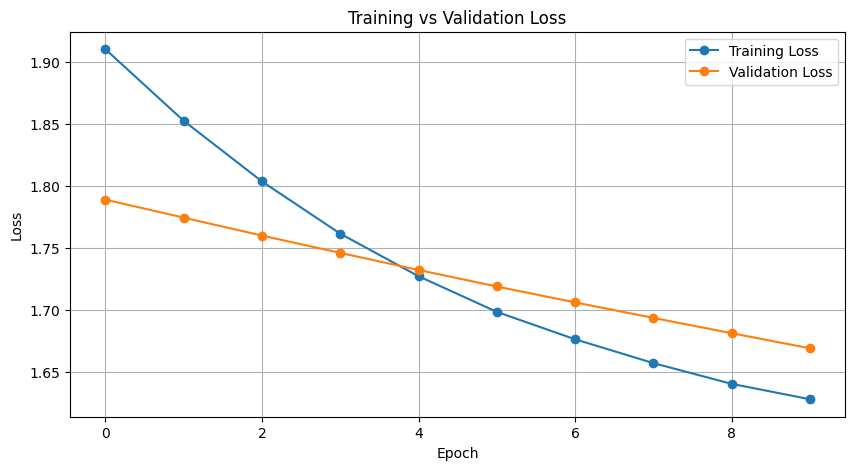

In [61]:
# Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(classifier_model_training_outputs.history['loss'], label='Training Loss', marker='o')
plt.plot(classifier_model_training_outputs.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

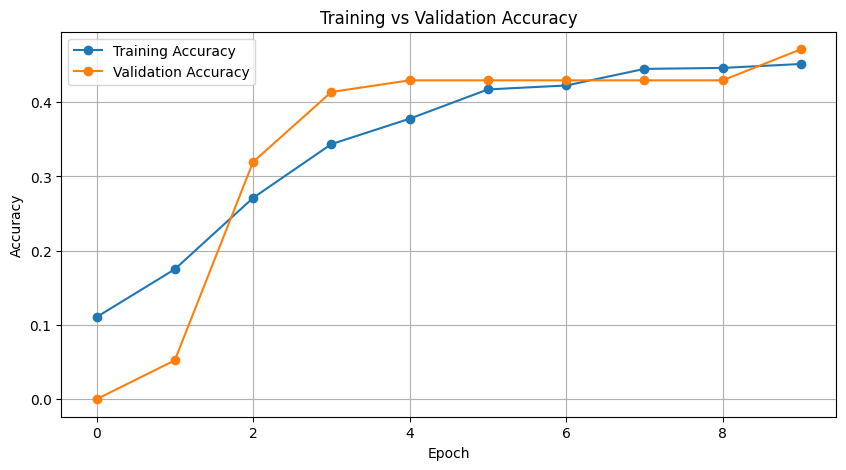

In [62]:
# Training vs Validation Accuracy for classifier model
plt.figure(figsize=(10, 5))
plt.plot(classifier_model_training_outputs.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(classifier_model_training_outputs.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Part A - Q3 D - Design new architecture/update existing architecture in attempt to improve the performance of the model.

In [68]:
optimized_classifier_model = Sequential()
optimized_classifier_model.add(Dense(64, input_shape = (11,), activation = 'relu'))
optimized_classifier_model.add(BatchNormalization())
optimized_classifier_model.add(Dropout(0.5))
optimized_classifier_model.add(Dense(32, input_shape = (11,), activation = 'relu'))
optimized_classifier_model.add(BatchNormalization())
optimized_classifier_model.add(Dropout(0.5))
optimized_classifier_model.add(Dense(6, activation = 'softmax'))
opt = optimizers.Adam(learning_rate= 0.001)
optimized_classifier_model.compile(optimizer=opt, loss = 'crossentropy',metrics=['accuracy'])
optimized_classifier_model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_43 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,430 (13.40 KB)

 Trainable params: 3,238 (12.65 KB)

 Non-trainable params: 192 (768.00 B)

### Recommendations & Insights

- In order for the model to learn better, I have two hidden layers with 64 neurons in one and 32 neurons in the second. Every hidden layer has batch normalization and dropout. Finally the final output layer has 6 neurons with softmax activation function.

In [69]:
#training of the model
optimized_classifier_model_training_outputs = optimized_classifier_model.fit(X_train, y_train_encoded, batch_size = 400, epochs = 10, verbose = 1,validation_split=0.2)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 261ms/step - accuracy: 0.1490 - loss: 2.7755 - val_accuracy: 0.1204 - val_loss: 1.7799
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.1323 - loss: 2.8505 - val_accuracy: 0.1204 - val_loss: 1.7725
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.1517 - loss: 2.6925 - val_accuracy: 0.1414 - val_loss: 1.7662
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.1414 - loss: 2.6522 - val_accuracy: 0.2408 - val_loss: 1.7599
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.1853 - loss: 2.6202 - val_accuracy: 0.2984 - val_loss: 1.7538
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.1957 - loss: 2.4958 - val_accuracy: 0.3194 - val_loss: 1.7477
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.1536 - loss: 2.5215 - val_accuracy: 0.3613 - val_loss: 1.7411
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.2276 - loss: 2.3566 - val_accuracy: 0.4084 - val_loss: 1.7345

### Recommendations & Insights

- The training loss has not shown a constant decrease with respect to each epoch but has seen an overall decrease. 
- The validation loss has been less than the training loss overall with a decrease in itself, hence proving that the model is learning correctly to perform multi-class classification.
- Training accuracy has been very less, however the validation accuracy has been high showing that the model has learnt pretty well.
-  Validation accuracy has shown a consistent improvement with respect to each epoch.

### Part A - Q3 E - Plot visuals as in Q3.C and share insights about difference observed in both the models.

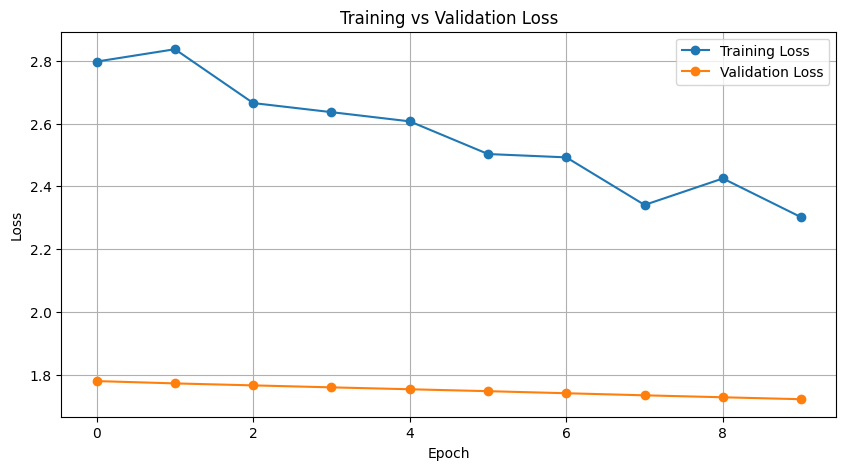

In [70]:
# Training vs Validation Loss for optimized classifier model
plt.figure(figsize=(10, 5))
plt.plot(optimized_classifier_model_training_outputs.history['loss'], label='Training Loss', marker='o')
plt.plot(optimized_classifier_model_training_outputs.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

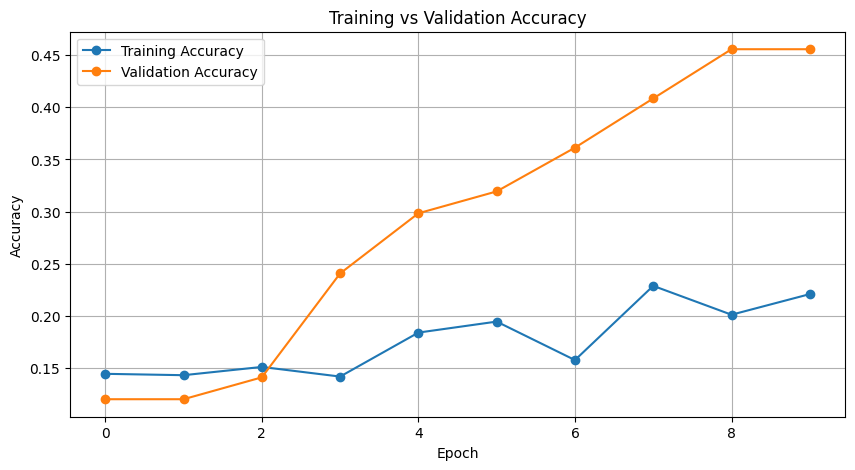

In [71]:
# Training vs Validation Accuracy for optimized classifier model
plt.figure(figsize=(10, 5))
plt.plot(optimized_classifier_model_training_outputs.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(optimized_classifier_model_training_outputs.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Final Insights and Recommendations

- The more the hidden layers in the model, model tends to generalize well rather than overfitting or underfitting.
- Dropout acts as a very important and fundamental layer such that certain neurons should have good grasp for certain aspects instead of making every neuron learn everything.
- Running over more than certain required epochs, model tends to overfit on the training data.
- Softmax activation function  acts as a very useful function for multi-class classification while relu function acts as great to remove vanishing gradient issues with the right architecture.

## Problem Statement - Part B

To build a digit classifier on the SVHN (Street View Housing Number) dataset. 

## Data Dictionary 

The SVHN is a real-world image dataset for developing machine learning and object recognition algorithms with the minimal requirement on data formatting but comes from a significantly harder, unsolved, real-world problem (recognizing digits and numbers in natural scene images). SVHN is obtained from house numbers in Google Street View images.
Where the labels for each of these images are the prominent number in that image i.e. 2,6,7 and 4 respectively.

### Part B - Q1 A - Read the .h5 file and assign to a variable.

In [185]:
filename = "Autonomous_Vehicles_SVHN_single_grey1.h5"
dictionary = {}
with File(filename, "r") as f:
    for key in f.keys():
        dictionary[key] = f[key][()]


### Part B - Q1 B - Print all the keys from the .h5 file

In [186]:
dictionary.keys()

dict_keys(['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val'])

### Part B - Q1 C - Split the data into X_train, X_test, Y_train, Y_test

In [187]:
X_train = dictionary['X_train']
X_val = dictionary ['X_val']
X_test = dictionary ['X_test']
y_train = dictionary['y_train']
y_val = dictionary['y_val']
y_test = dictionary['y_test']

### Part B - Q2 A - Print shape of all the 4 data split into x, y, train, test to verify if x & y is in sync.

In [188]:
print ("X_train shape:",X_train.shape)
print ("X_val shape:",X_val.shape)
print ("X_test shape:",X_test.shape)

print ("y_train shape:",y_train.shape)
print ("y_val shape:",y_val.shape)
print ("y_test hape:",y_test.shape)

X_train shape: (42000, 32, 32)
X_val shape: (60000, 32, 32)
X_test shape: (18000, 32, 32)
y_train shape: (42000,)
y_val shape: (60000,)
y_test hape: (18000,)


### Insights 

- X_train has 42000 images of 32 * 32 scale
- X_val has 60000 images of 32 * 32 scale
- X_test has 18000 images of 32 * 32 scale

### Part B - Q2 B - Visualise first 10 images in train data and print its corresponding labels.

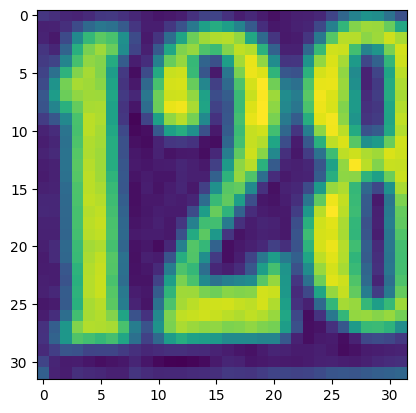

Label:  2


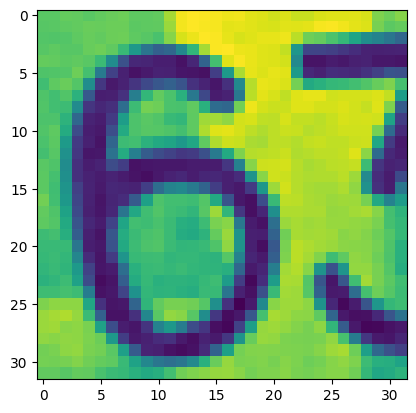

Label:  6


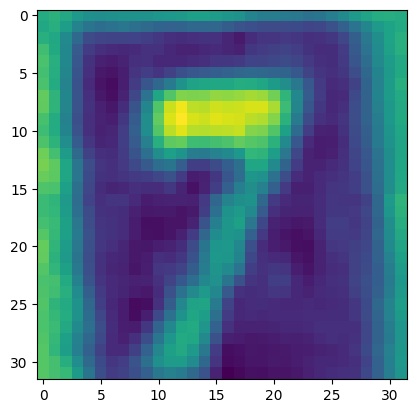

Label:  7


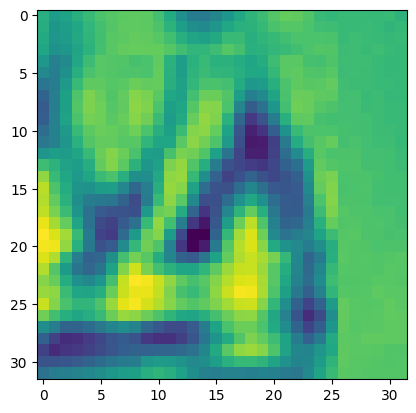

Label:  4


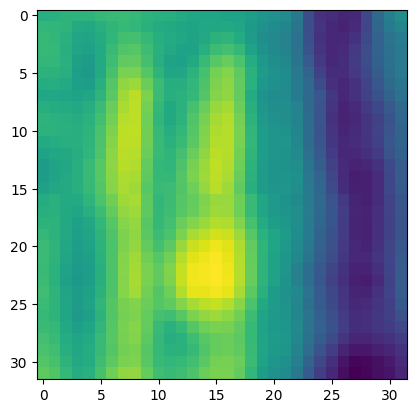

Label:  4


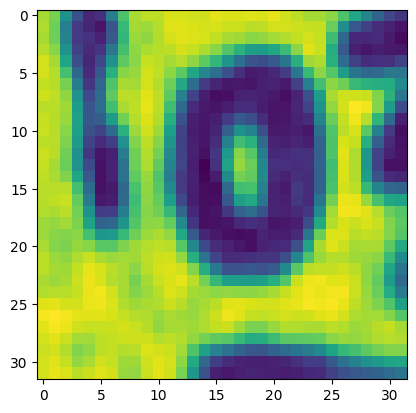

Label:  0


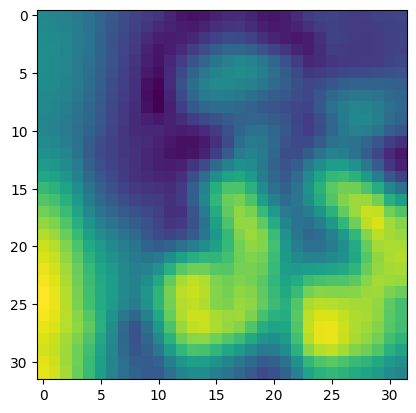

Label:  3


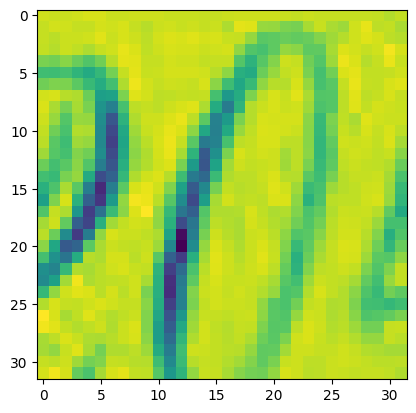

Label:  0


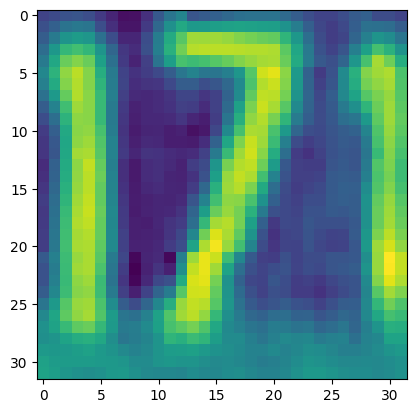

Label:  7


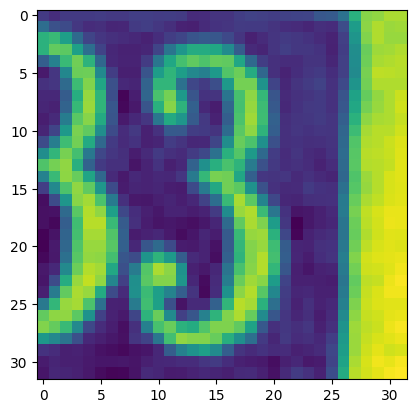

Label:  3


In [189]:
for i in  range(0,10):
    plt.imshow(X_train[i])
    plt.show()
    print('Label: ', y_train[i])

### Part B - Q2 C -Reshape all the images with appropriate shape update the data in same variable.

In [190]:
X_train = X_train.reshape((X_train.shape[0], -1))
X_val= X_val.reshape((X_val.shape[0], -1))
X_test = X_test.reshape((X_test.shape[0], -1))

print ("X_train shape:",X_train.shape)
print ("X_val shape:",X_val.shape)
print ("X_test shape:",X_test.shape)

X_train shape: (42000, 1024)
X_val shape: (60000, 1024)
X_test shape: (18000, 1024)


### Insights 

- The images are being reshaped from (n,32,32) to (n,1024)

### Part B - Q2 D - Normalise the images i.e. Normalise the pixel values.

In [191]:
X_train = preprocessing.normalize(X_train)
X_val = preprocessing.normalize(X_val)
X_test = preprocessing.normalize(X_test)

print ("X_train shape:",X_train.shape)
print ("X_val shape:",X_val.shape)
print ("X_test shape:",X_test.shape)

X_train shape: (42000, 1024)
X_val shape: (60000, 1024)
X_test shape: (18000, 1024)


### Insights

- Performing normalization so that the model does not over learn for any particular entry in the dataset

### Part B - Q2 E - Transform Labels into format acceptable by Neural Network

In [192]:
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test  = np.array(y_test)

#categorical encoding on labels
y_train_categorical = to_categorical(y_train)
y_val_categorical = to_categorical(y_val)
y_test_categorical = to_categorical(y_test)

print ("y_train shape:",y_train_categorical.shape)
print ("y_val shape:",y_val_categorical.shape)
print ("y_test hape:",y_test_categorical.shape)

y_train shape: (42000, 10)
y_val shape: (60000, 10)
y_test hape: (18000, 10)


### Insights 

-  Categorical encoding is performed so that the output values can be encoded for multi-class classification related processes.

### Part B - Q2 F - Print total Number of classes in the Dataset.

In [200]:
np.unique(y_train)


array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

### Insights 

- There are 10 classes in the dataset

### Part B - Q3 A - Design a Neural Network to train a classifier.

In [213]:
image_classifier_model  = Sequential()
image_classifier_model.add(Dense(128, input_shape = (1024, ),kernel_initializer="he_normal"))
image_classifier_model.add(BatchNormalization())
image_classifier_model.add(Activation('relu'))
image_classifier_model.add(Dropout(0.3))
image_classifier_model.add(Dense(64,kernel_initializer="he_normal"))
image_classifier_model.add(BatchNormalization())
image_classifier_model.add(Activation('relu'))
image_classifier_model.add(Dropout(0.3))
image_classifier_model.add(Dense(32,kernel_initializer="he_normal"))
image_classifier_model.add(BatchNormalization())
image_classifier_model.add(Activation('relu'))
image_classifier_model.add(Dropout(0.3))
image_classifier_model.add(Dense(16,kernel_initializer="he_normal"))
image_classifier_model.add(BatchNormalization())
image_classifier_model.add(Activation('relu'))
image_classifier_model.add(Dropout(0.3))
image_classifier_model.add(Dense(10,kernel_initializer="he_normal"))
image_classifier_model.add(Activation('softmax'))
adam = optimizers.Adam(learning_rate = 0.001)
image_classifier_model.compile(optimizer = adam, loss = 'crossentropy', metrics = ['accuracy'])
image_classifier_model.summary()


c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_146 (Dense)               │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_103         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_60 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_92 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_147 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_104         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_61 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_93 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_148 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_105         │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_62 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_94 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_149 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_106         │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_63 (Activation)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_95 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_150 (Dense)               │ (None, 10)             │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_64 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143,194 (559.35 KB)

 Trainable params: 142,714 (557.48 KB)

 Non-trainable params: 480 (1.88 KB)

### Insights 

- The above model is made of 4 hidden layers, first has 128 neurons, second has 64 neurons, third has 32 neurons, and last hidden layer has 16 neurons. Each neuron in the hidden layer has ReLu activated function. 
- The output layer has 10 neurons for prediction with  a softmax activation function. 
- Each hidden layer has batch normalization and dropout layer of 30%, which aids in better learning of the classification task at hand. 

### Part B - Q3 B - Train the classifier using previously designed Architecture (Use best suitable parameters).

In [214]:
image_classifier_model_outputs = image_classifier_model.fit(X_train,y_train_categorical,batch_size=200,epochs=50,verbose=1,validation_data=(X_val,y_val_categorical))

Epoch 1/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1294 - loss: 2.4778 - val_accuracy: 0.1350 - val_loss: 2.2609
Epoch 2/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.2684 - loss: 2.0013 - val_accuracy: 0.1742 - val_loss: 2.2330
Epoch 3/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3569 - loss: 1.7721 - val_accuracy: 0.4562 - val_loss: 1.6291
Epoch 4/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4266 - loss: 1.6091 - val_accuracy: 0.5979 - val_loss: 1.2965
Epoch 5/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4804 - loss: 1.4887 - val_accuracy: 0.5213 - val_loss: 1.3360
Epoch 6/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5325 - loss: 1.3691 - val_accuracy: 0.5931 - val_loss: 1.2722
Epoch 7/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5609 - loss: 1.2931 - val_accuracy: 0.5753 - val_loss: 1.3705
Epoch 8/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5779 - loss: 1.2559 - val_accur

### Insights

- Overall the accuracy for validation is better than training accuracy and the loss is lot less than the training loss, suggesting that the model has not overfit on the training data.
- However, the current number of epochs suggest that model has reached optimal minimum.

### Part B - Q3 C - Evaluate performance of the model with appropriate metrics.

In [218]:
image_classifier_model_outputs_test = image_classifier_model.evaluate(X_test,y_test_categorical)

563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7980 - loss: 0.6681


### Insights

- The overall accuracy during evaluation on the test data has been nearly 79% with a loss of 0.67, which is little high as compared to the validation loss

### Part B - Q3 D - Plot the training loss, validation loss vs number of epochs and training accuracy, validation accuracy vs number of epochs plot and write your observations on the same.

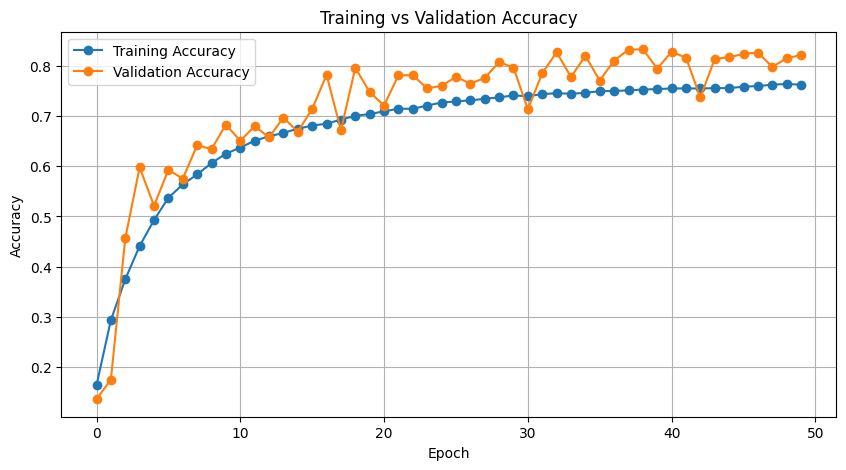

In [222]:
# Training vs Validation Accuracy for image classifier model
plt.figure(figsize=(10, 5))
plt.plot(image_classifier_model_outputs.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(image_classifier_model_outputs.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

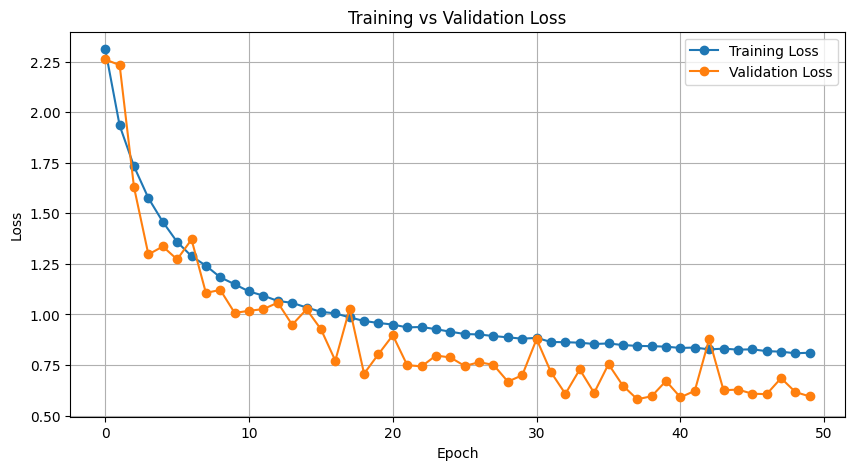

In [224]:
# Training vs Validation Loss for image classifier model
plt.figure(figsize=(10, 5))
plt.plot(image_classifier_model_outputs.history['loss'], label='Training Loss', marker='o')
plt.plot(image_classifier_model_outputs.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Final Insights

- There are instances in both loss and accuracy wherein the validation has been more than the training. However, in the overall scenerio the validation has performed slightly better than the training suggesting the model has not overfit.
- But for testing the accuracy has been little less than the validation accuracy suggesting the number of datapoints in training data might be little less.

### Final Recommendations

- The more the number of hidden layers, the model generalizes well over the task which overfits on the training data if the number of hidden layers are less.
- The use of correct activation function is extremely essential to introduce non-linearity for the model to  better learn and adapt to the given task.
- The BatchNormalization and Dropout layer proves to be extremely essential for the model so that particular neurons function better in certain scenerios as compared to others. 
- Having the correct size of datasets in the correct steps (training,validation,testing) is extremely important so that model learns well about the data.